In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [8]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


In [9]:
display(apps.head())

display(reviews.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [10]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [11]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [12]:
print(apps.isnull().sum())

print("\n----------------------------\n")

print(reviews.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

----------------------------

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [13]:
print("Duplicate Apps Before:", apps.duplicated(subset="App").sum())

apps = apps.drop_duplicates(subset="App", keep="first")

print("Duplicate Apps After:", apps.duplicated(subset="App").sum())

Duplicate Apps Before: 1181
Duplicate Apps After: 0


In [14]:
apps = apps.dropna(subset=["Rating"])

print("Dataset Shape:", apps.shape)

Dataset Shape: (8197, 13)


In [15]:
apps["Type"] = apps["Type"].fillna(apps["Type"].mode()[0])

apps["Content Rating"] = apps["Content Rating"].fillna(
    apps["Content Rating"].mode()[0]
)

In [16]:
apps["Current Ver"] = apps["Current Ver"].fillna("Unknown")

apps["Android Ver"] = apps["Android Ver"].fillna("Unknown")

In [17]:
print(apps.isnull().sum())

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [18]:
apps = apps.drop(10472, errors="ignore")

print("Dataset Shape:", apps.shape)

Dataset Shape: (8196, 13)


In [19]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"])

In [20]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(int)
)

In [21]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

In [22]:
def clean_size(size):
    if size == "Varies with device":
        return np.nan
    elif "M" in size:
        return float(size.replace("M", ""))
    elif "k" in size:
        return float(size.replace("k", "")) / 1024
    else:
        return np.nan

apps["Size"] = apps["Size"].apply(clean_size)

apps["Size"] = apps["Size"].fillna(apps["Size"].median())

In [23]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   object 
 1   Category        8196 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            8196 non-null   float64
 5   Installs        8196 non-null   int64  
 6   Type            8196 non-null   object 
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   object 
 9   Genres          8196 non-null   object 
 10  Last Updated    8196 non-null   object 
 11  Current Ver     8196 non-null   object 
 12  Android Ver     8196 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 896.4+ KB


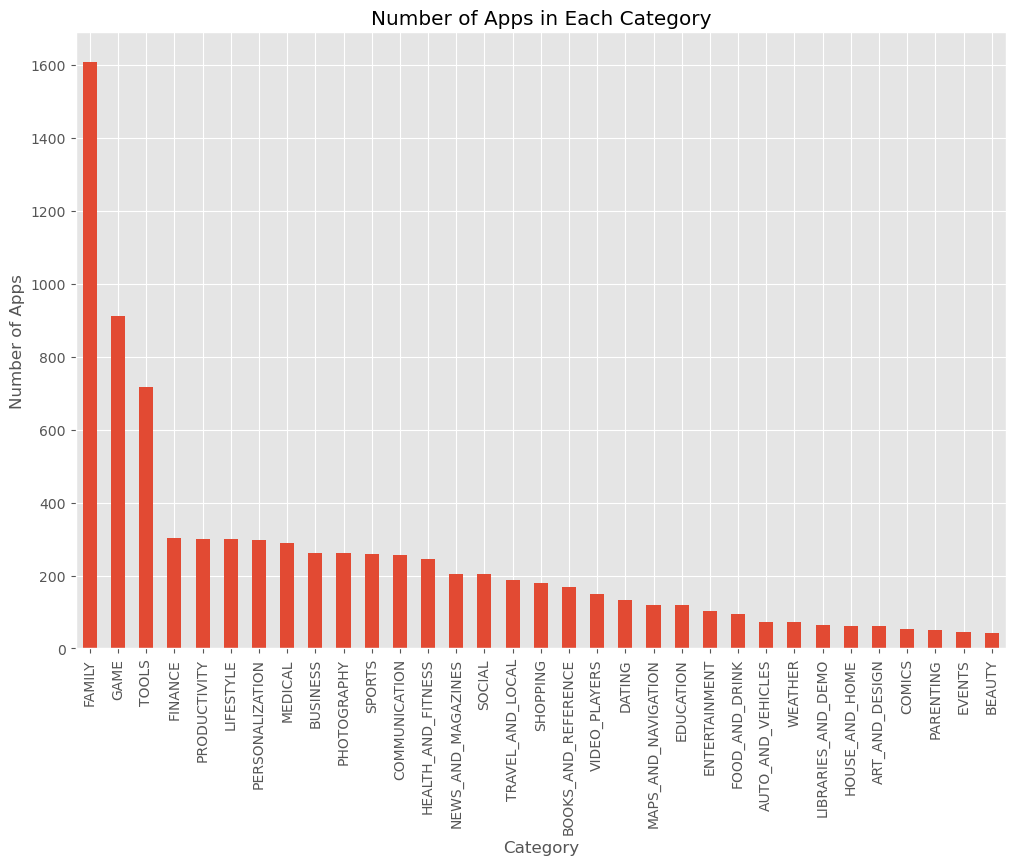

In [24]:
plt.figure(figsize=(12,8))

apps["Category"].value_counts().plot(kind="bar")

plt.title("Number of Apps in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=90)

plt.show()

In [25]:
category_count = apps["Category"].value_counts()

display(category_count.head(10))

Category
FAMILY             1608
GAME                912
TOOLS               718
FINANCE             302
PRODUCTIVITY        301
LIFESTYLE           301
PERSONALIZATION     298
MEDICAL             290
BUSINESS            263
PHOTOGRAPHY         263
Name: count, dtype: int64

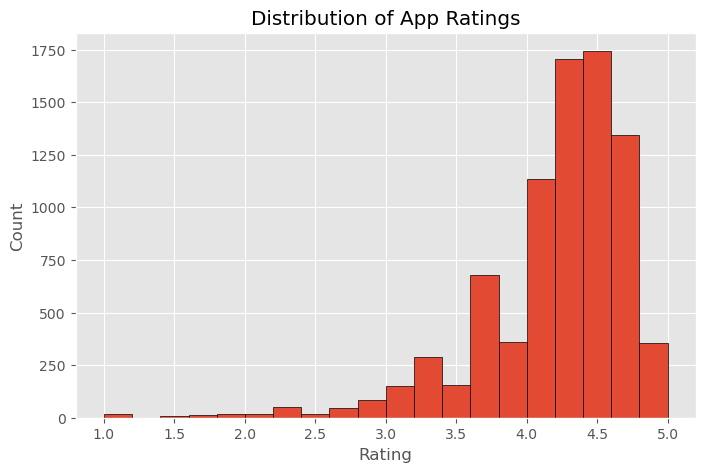

In [26]:
plt.figure(figsize=(8,5))

plt.hist(apps["Rating"], bins=20, edgecolor="black")

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [27]:
avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_rating)

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230000
SPORTS                 4.216154
AUTO_AND_VEHICLES      4.190411
PRODUCTIVITY           4.183389
COMICS                 4.181481
FAMILY                 4.179664
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.172340
MEDICAL                4.166552
PHOTOGRAPHY            4.157414
HOUSE_AND_HOME         4.150000
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121484
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044595
TOOLS                  4.039554

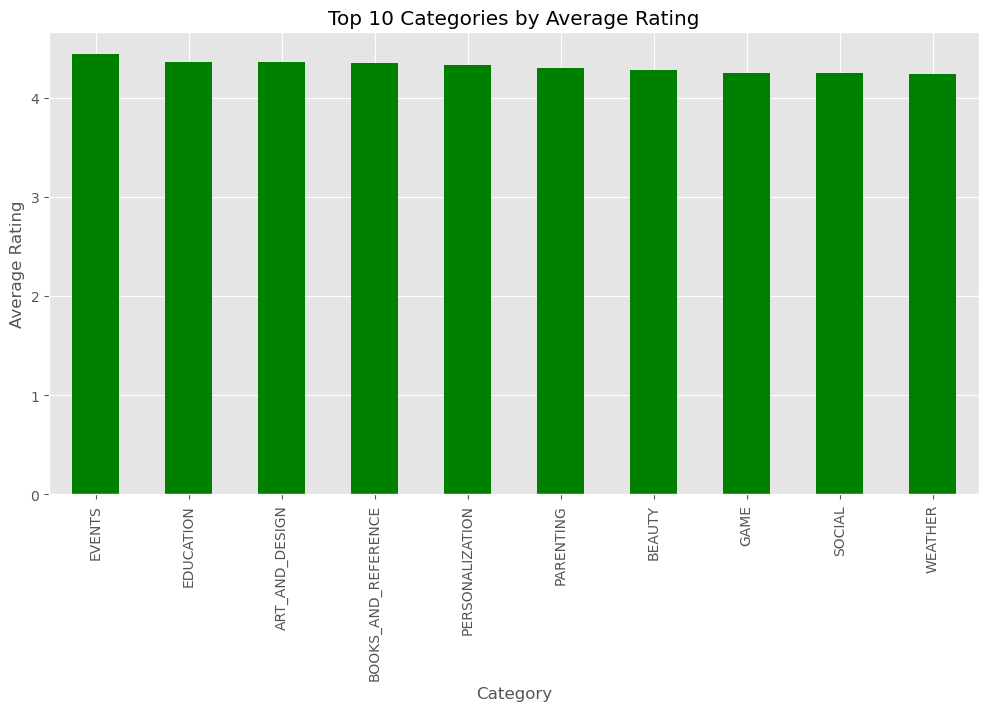

In [28]:
plt.figure(figsize=(12,6))

avg_rating.head(10).plot(kind="bar", color="green")

plt.title("Top 10 Categories by Average Rating")

plt.ylabel("Average Rating")

plt.show()

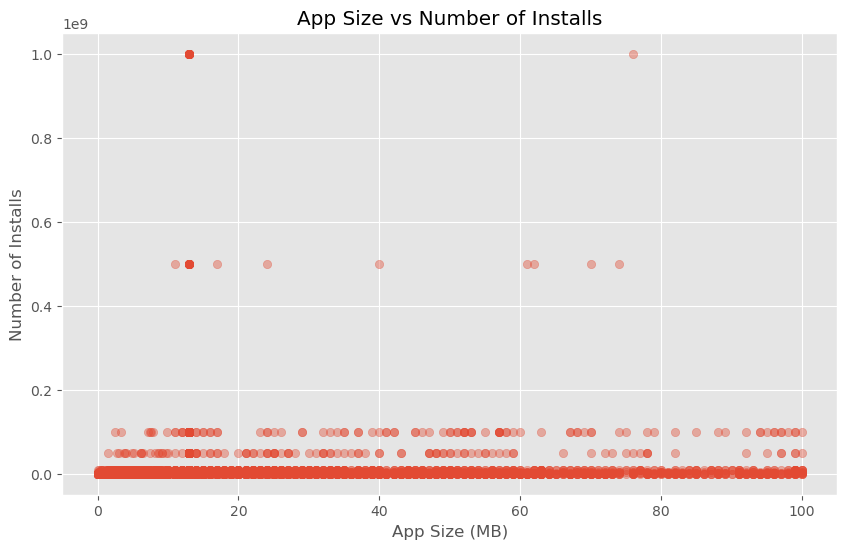

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(apps["Size"], apps["Installs"], alpha=0.4)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()

In [30]:
print("Correlation between Size and Installs:")

print(apps[["Size","Installs"]].corr())

Correlation between Size and Installs:
              Size  Installs
Size      1.000000  0.027786
Installs  0.027786  1.000000


Type
Free    7592
Paid     604
Name: count, dtype: int64

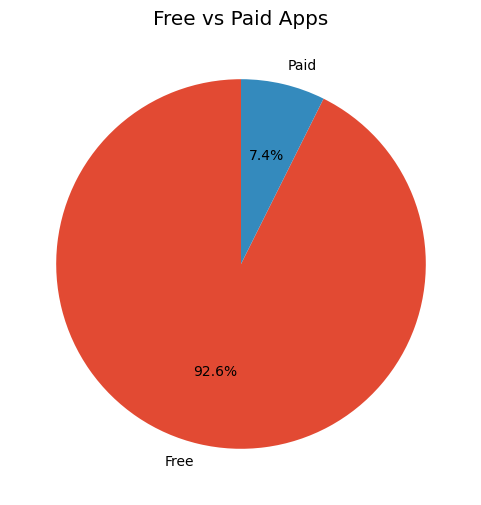

In [31]:
type_count = apps["Type"].value_counts()

display(type_count)

plt.figure(figsize=(6,6))

plt.pie(
    type_count,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Free vs Paid Apps")

plt.show()

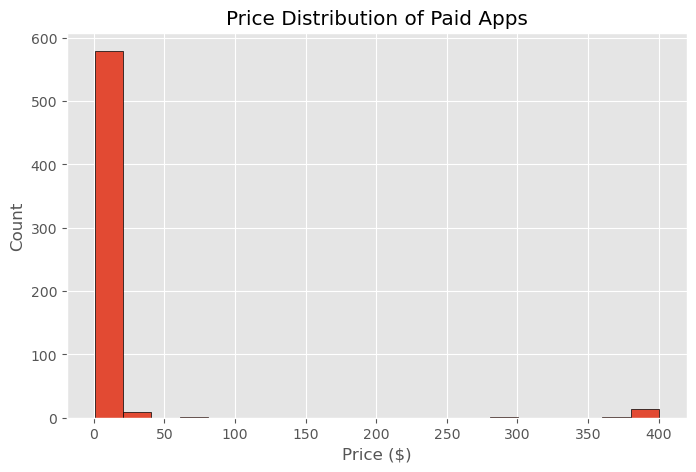

In [32]:
paid_apps = apps[apps["Type"]=="Paid"]

plt.figure(figsize=(8,5))

plt.hist(
    paid_apps["Price"],
    bins=20,
    edgecolor="black"
)

plt.title("Price Distribution of Paid Apps")

plt.xlabel("Price ($)")
plt.ylabel("Count")

plt.show()

In [33]:
apps["Estimated Revenue"] = apps["Price"] * apps["Installs"]

revenue = (
    apps.groupby("Category")["Estimated Revenue"]
    .sum()
    .sort_values(ascending=False)
)

display(revenue.head(10))

Category
FAMILY             1.136738e+08
LIFESTYLE          5.758394e+07
GAME               4.068784e+07
FINANCE            2.572664e+07
PHOTOGRAPHY        8.546050e+06
PERSONALIZATION    6.796310e+06
MEDICAL            5.872355e+06
TOOLS              5.462910e+06
SPORTS             4.706154e+06
PRODUCTIVITY       4.304452e+06
Name: Estimated Revenue, dtype: float64

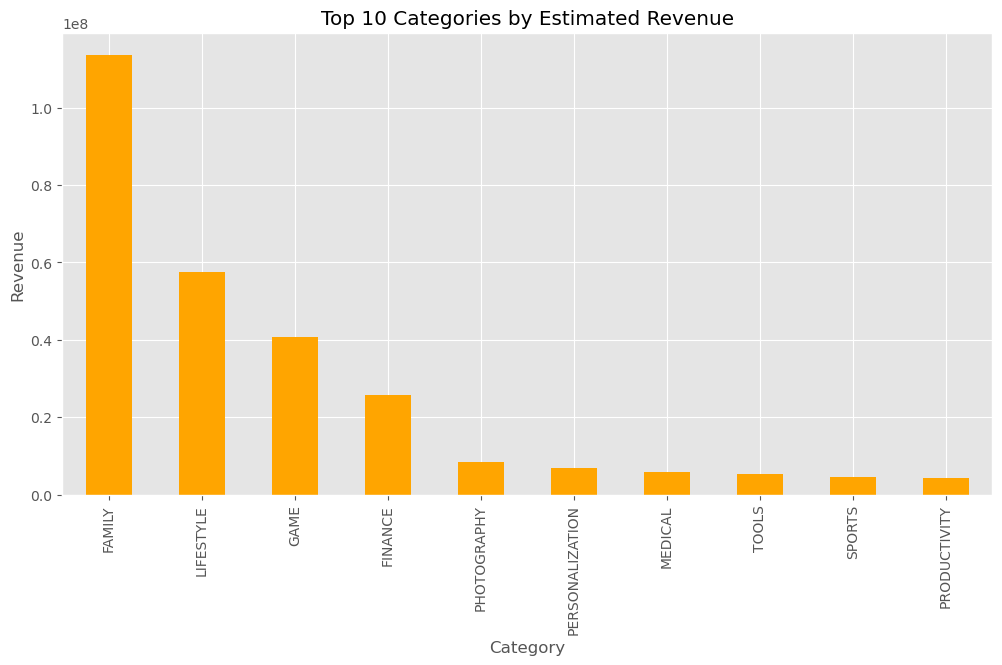

In [34]:
plt.figure(figsize=(12,6))

revenue.head(10).plot(kind="bar", color="orange")

plt.title("Top 10 Categories by Estimated Revenue")

plt.ylabel("Revenue")

plt.show()

In [35]:
!pip install vaderSentiment plotly

Defaulting to user installation because normal site-packages is not writeable


In [36]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px

In [37]:
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


In [38]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [39]:
import sys
!{sys.executable} -m pip install vaderSentiment plotly

Defaulting to user installation because normal site-packages is not writeable


In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px

In [41]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px

In [42]:
analyzer = SentimentIntensityAnalyzer()

In [43]:
def get_sentiment(text):

    if pd.isna(text):
        return "Neutral"

    score = analyzer.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"
    elif score["compound"] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [45]:
reviews["Predicted_Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Predicted_Sentiment
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,Positive
2,10 Best Foods for You,NaN,NaN,NaN,NaN,Neutral
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,Positive
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,Positive


In [46]:
reviews["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Neutral     31169
Positive    25604
Negative     7522
Name: count, dtype: int64

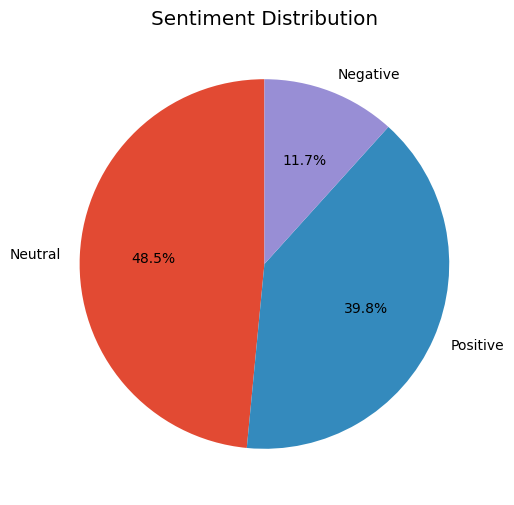

In [47]:
plt.figure(figsize=(6,6))

reviews["Predicted_Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()

In [48]:
merged = pd.merge(
    apps,
    reviews,
    on="App",
    how="inner"
)

merged.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Estimated Revenue,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Predicted_Sentiment
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000,Negative
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,It bad >:(,Negative,-0.725,0.833333,Negative
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,like,Neutral,0.000,0.000000,Positive
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,NaN,NaN,NaN,NaN,Neutral
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,I love colors inspyering,Positive,0.500,0.600000,Positive


In [49]:
sentiment_category = pd.crosstab(
    merged["Category"],
    merged["Predicted_Sentiment"]
)

display(sentiment_category)

Predicted_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,53,211,284
AUTO_AND_VEHICLES,14,350,239
BEAUTY,69,319,203
BOOKS_AND_REFERENCE,111,534,467
BUSINESS,159,728,713
COMICS,1,160,39
COMMUNICATION,242,1350,648
DATING,402,1620,1076
EDUCATION,81,1086,693


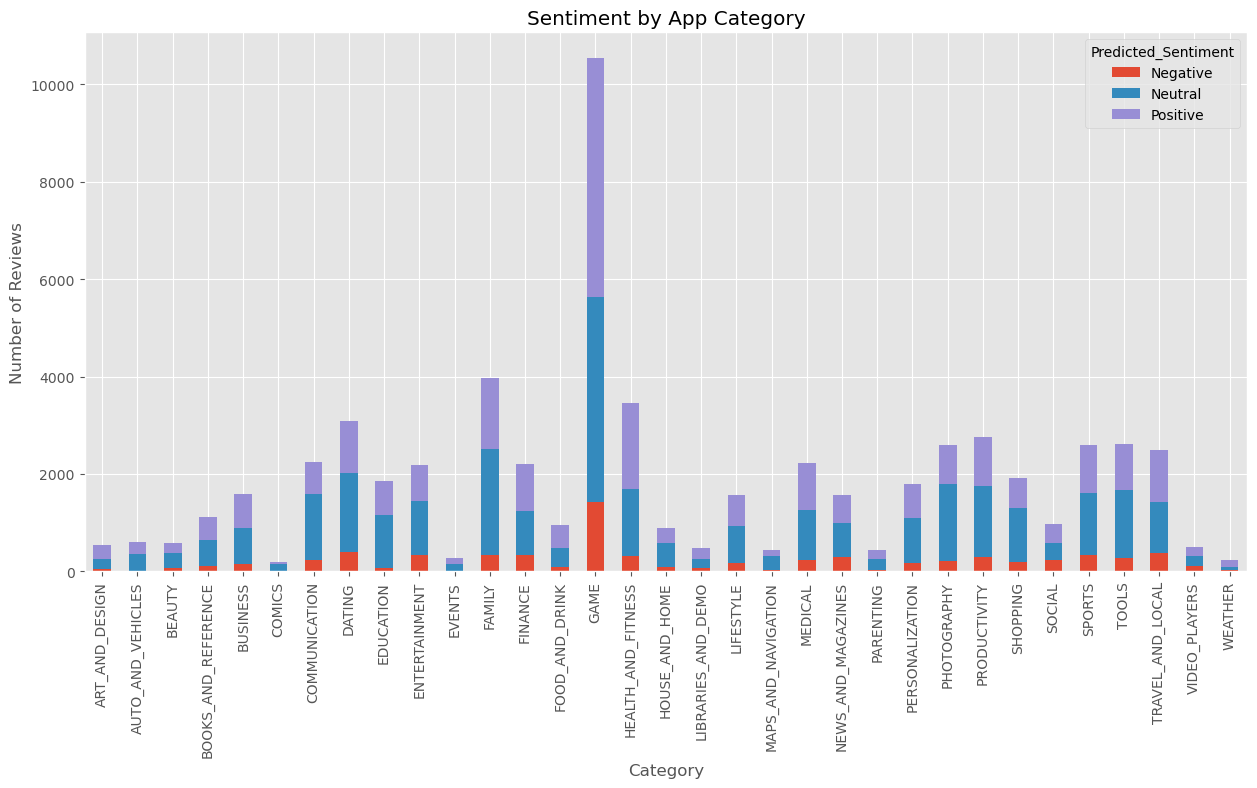

In [50]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15,7)
)

plt.title("Sentiment by App Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.show()

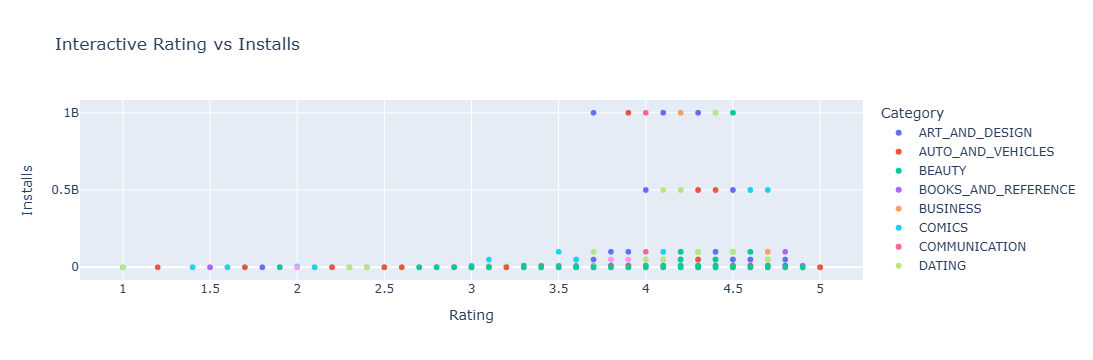

In [51]:
fig = px.scatter(
    apps,
    x="Rating",
    y="Installs",
    color="Category",
    hover_name="App",
    title="Interactive Rating vs Installs"
)

fig.show()

# Conclusion

### Key Insights

1. The FAMILY category contains the highest number of apps, making it one of the most competitive categories on the Google Play Store.

2. Most apps have ratings between 4.0 and 4.7, indicating generally positive user satisfaction.

3. Around 92% of applications are free, while only a small percentage are paid.

4. Paid apps are generally low-priced, although a few premium apps are significantly more expensive.

5. The estimated revenue analysis shows that the FAMILY and GAME categories generate the highest potential revenue.

6. Sentiment analysis reveals that most user reviews are Neutral or Positive, while Negative reviews form a much smaller percentage.

### Recommendation for Developers

• Launching an app in categories with high user engagement and positive sentiment can improve success.
• Maintaining high ratings and responding to user feedback can increase downloads.
• Freemium pricing models may attract more users than paid-only applications.